# OVERVIEW

This notebook serves as analysis of the attached src .py files, and an example of how to use them.

This notebook is split into three parts, the first part of which we try to fit a given model type to technical indicators and see what limitations we encounter. In the second part we study a cross-sectional excess return formulation and its applications, and what signals we can find in predicting market direction. In part 3, we start an ongoing test surrounding the use of the P-E ratio and RoE as potential signals for performance.

In [3]:
#importing all packages/functions necessary
import numpy as np
import pandas as pd
from scipy import stats

import sys
sys.path.append('../src')
sys.path.append('../../past_market_analysis/src')
from data_loader import fetch_price_data, get_sp500_tickers

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from features import build_features, build_multi_ticker_dataset, build_fundamental_features, start_forward_tracking, forward_evaluation_tracking
from labels import simple_labels, triple_barrier_labels, excess_return_target
from walk_forward import walk_forward_evaluate, walk_forward_evaluate_pooled, walk_forward_confident_only, evaluate_by_direction, strategy_vs_buy_hold, walk_forward_ranked_portfolio, momentum_baseline_single, momentum_baseline_sweep, walk_forward_momentum_rule
from plotting import plot_trade_outcomes, plot_momentum_sweep, plot_forward_test_setup


## PART 1

Begin by creating a dataframe containing many technical indicators of future direction as seen in the technical_analysis project.

In [4]:
ticker = "AAPL"
df = fetch_price_data(ticker, period="10y")
spy = fetch_price_data("SPY", period="10y")

features = build_features(df, spy_df=spy)

We create labels to indicate when to buy/sell. A simple label is simple (hence the name), if the forward return is above our threshold, then buy. A triple barrier label is where we have a profit_multipler, stop_multiplier and we label the trade to which barrier it hits first (assuming it hits either). Multipliers chosen at a 2:1 profit-stop ratio so that we can be incorrect half of the time and still profit. Both barriers scale with current volatility

In [5]:
labels_simple, fwd_ret = simple_labels(df, horizon=5, threshold=0.0)
print("Simple labels (5-day forward return > 0):")
print(f"  Class balance: {labels_simple.value_counts().to_dict()}")
print(f"  Positive rate: {labels_simple.mean():.4f}")

labels_tb, hold_days, tb_return = triple_barrier_labels(df, horizon=10)
print("\nTriple barrier (10-day horizon, 2:1 reward/risk):")
print(f"  Class balance: {labels_tb.value_counts().to_dict()}")
print(f"  Positive rate: {labels_tb.mean():.4f}")
print(f"  Avg holding period: {hold_days.mean():.2f} days")
print(f"  Avg return when label=1: {tb_return[labels_tb==1].mean()*100:.2f}%")
print(f"  Avg return when label=0: {tb_return[labels_tb==0].mean()*100:.2f}%")

Simple labels (5-day forward return > 0):
  Class balance: {1.0: 1467, 0.0: 1041}
  Positive rate: 0.5849

Triple barrier (10-day horizon, 2:1 reward/risk):
  Class balance: {1.0: 1250, 0.0: 1232}
  Positive rate: 0.5036
  Avg holding period: 4.57 days
  Avg return when label=1: 3.82%
  Avg return when label=0: -2.71%


In [6]:
features_clean = features.dropna()
labels_clean = labels_tb.reindex(features_clean.index)
fwd_ret_clean = tb_return.reindex(features_clean.index)

fold_results, oof_pred, oof_proba = walk_forward_evaluate(
    lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1),
    features_clean, labels_clean, fwd_ret_clean,
    train_size=500, test_size=63, embargo=10)

print(fold_results.to_string())
print(f"\nMean ROC-AUC: {fold_results['roc_auc'].mean():.4f}")
print(f"Mean accuracy: {fold_results['accuracy'].mean():.4f}")
print(f"Mean strategy return per trade: {fold_results['strategy_return'].mean()*100:.3f}%")

    fold train_start test_start   test_end  n_train  n_test  accuracy   roc_auc  strategy_return
0      0  2017-06-05 2019-06-14 2019-09-12      500      63  0.587302  0.550998         0.005414
1      1  2017-09-01 2019-09-13 2019-12-11      500      63  0.253968  0.690160        -0.018699
2      2  2017-12-01 2019-12-12 2020-03-13      500      63  0.412698  0.397959        -0.002368
3      3  2018-03-06 2020-03-16 2020-06-12      500      63  0.777778  0.815359         0.035459
4      4  2018-06-05 2020-06-15 2020-09-11      500      63  0.539683  0.465217         0.005983
5      5  2018-09-04 2020-09-14 2020-12-10      500      63  0.428571  0.327621        -0.000205
6      6  2018-12-03 2020-12-11 2021-03-15      500      63  0.396825  0.462105         0.001760
7      7  2019-03-07 2021-03-16 2021-06-14      500      63  0.523810  0.435354         0.007464
8      8  2019-06-06 2021-06-15 2021-09-13      500      63  0.698413  0.266746         0.012352
9      9  2019-09-05 2021-09-1

We see the results are middling, as we buy/sell at times which have no rationale. We see the strategy return has a general correlation with the ROC-AUC, but we test to see whether this is statistically significant, and whether this holds over the whole of the market and not one cherry picked ticker. Start by adding the features to a pooled feature of tickers

In [7]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM", "WMT", "PG", "HD", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ADBE", "CRM"]

pooled = build_multi_ticker_dataset(tickers, period="10y", horizon=10)

print(f"Tickers included: {pooled['ticker'].nunique()}")
print(f"Date range: {pooled.index.min()} to {pooled.index.max()}")


1 Failed download:
['CRM']: TypeError("'NoneType' object is not subscriptable")


Successfully loaded: 19 / 20 tickers
Failed or insufficient data: 1 (['CRM'])
Tickers included: 19
Date range: 2016-08-18 00:00:00 to 2026-08-18 00:00:00


Now run the same test on this list of tickers

In [8]:
feature_cols = [c for c in pooled.columns if c not in ['label', 'fwd_return', 'ticker']]

results = walk_forward_evaluate_pooled(lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), pooled, feature_cols, train_size=250, test_size=63, embargo=10)

print(results.to_string())
print(f"\nMean ROC-AUC: {results['roc_auc'].mean():.4f}")

t, p = stats.ttest_1samp(results['roc_auc'].dropna(), 0.5)
print(f"ROC-AUC vs 0.5: t={t:.3f}, p={p:.4f}")
t, p = stats.ttest_1samp(results['strategy_return'], 0)
print(f"Strategy return vs 0: t={t:.3f}, p={p:.4f}")

    fold train_start test_start   test_end  n_train  n_test  accuracy   roc_auc  strategy_return
0      0  2017-06-05 2018-06-15 2018-09-13     4750    1197  0.460317  0.448326        -0.003282
1      1  2017-09-01 2018-09-14 2018-12-13     4750    1197  0.441938  0.577649        -0.002277
2      2  2017-12-01 2018-12-14 2019-03-18     4750    1197  0.411028  0.397668        -0.006755
3      3  2018-03-06 2019-03-19 2019-06-17     4750    1197  0.503759  0.494408        -0.003957
4      4  2018-06-05 2019-06-18 2019-09-16     4750    1197  0.518797  0.491826        -0.000019
5      5  2018-09-04 2019-09-17 2019-12-13     4750    1197  0.414369  0.418605        -0.008169
6      6  2018-12-03 2019-12-16 2020-03-17     4750    1197  0.543860  0.467707         0.004686
7      7  2019-03-07 2020-03-18 2020-06-16     4750    1197  0.517962  0.469742         0.005074
8      8  2019-06-06 2020-06-17 2020-09-15     4750    1197  0.486216  0.489104         0.005481
9      9  2019-09-05 2020-09-1

See immediately that the strategy return is less than 0. It could be due to the fact that the machine is buying at every point in time without any rationale as to when it buys, or that the system does not depend on these technical indicators. We test the first with a confidence level.}

In [9]:
fold_results = walk_forward_confident_only(lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1),  pooled, feature_cols, train_size=250, test_size=63, embargo=10)

print(fold_results.to_string())
print(f"\nMean Confident ROC-AUC: {fold_results['roc_auc_confident'].mean():.4f}")

t, p = stats.ttest_1samp(fold_results['roc_auc_confident'].dropna(), 0.5)
print(f"ROC-AUC Confident vs 0.5: t={t:.3f}, p={p:.4f}")
t, p = stats.ttest_1samp(fold_results['strategy_return'], 0)
print(f"Strategy return vs 0: t={t:.3f}, p={p:.4f}")

    fold  n_confident  n_total  roc_auc_all  roc_auc_confident  strategy_return
0      0          136     1197     0.448326           0.457205        -0.011495
1      1          172     1197     0.577649           0.616997         0.010996
2      2          226     1197     0.397668           0.400381        -0.011274
3      3           95     1197     0.494408           0.394007        -0.016136
4      4          299     1197     0.491826           0.468510        -0.001467
5      5          194     1197     0.418605           0.570572        -0.019188
6      6          180     1197     0.467707           0.466250        -0.009109
7      7          108     1197     0.469742           0.292121        -0.044008
8      8           51     1197     0.489104           0.517742         0.001690
9      9           45     1197     0.420991           0.426267        -0.032831
10    10           27     1197     0.495909           0.527473         0.012019
11    11           95     1197     0.514

See that the confident ROC-AUC is not signifcant compared to 0.5, so even when we're confident, we're not more than 50% confident. We still see that the strategy return is negative, meaning our machine is still bad at predicting the direction of travel. This is only with one confidence level, so test with numerous ones below.

In [10]:
for thresh in [0.55, 0.58, 0.6, 0.65]:
    result = walk_forward_confident_only(
        lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1),
        pooled, feature_cols, train_size=250, test_size=63, embargo=10,
        confidence_threshold=thresh)
    n_folds = len(result)
    t, p = stats.ttest_1samp(result['strategy_return'].dropna(), 0)
    print(f"Threshold {thresh}: {n_folds} folds, mean return {result['strategy_return'].mean()*100:.3f}%, "
          f"t={t:.3f}, p={p:.4f}")

Threshold 0.55: 32 folds, mean return -0.313%, t=-2.593, p=0.0144
Threshold 0.58: 32 folds, mean return -0.477%, t=-2.642, p=0.0128
Threshold 0.6: 32 folds, mean return -0.533%, t=-2.242, p=0.0322
Threshold 0.65: 29 folds, mean return -1.619%, t=-1.740, p=0.0928


See even with changing confidence thresholds, the strategy is still mostly still significantly negative. It is important to note that a negative strategy does not mean selling more. It means we are predicting the incorrect direction (if we predict sell, the price goes up, and vice versa). We show a visual of the confident trades below.

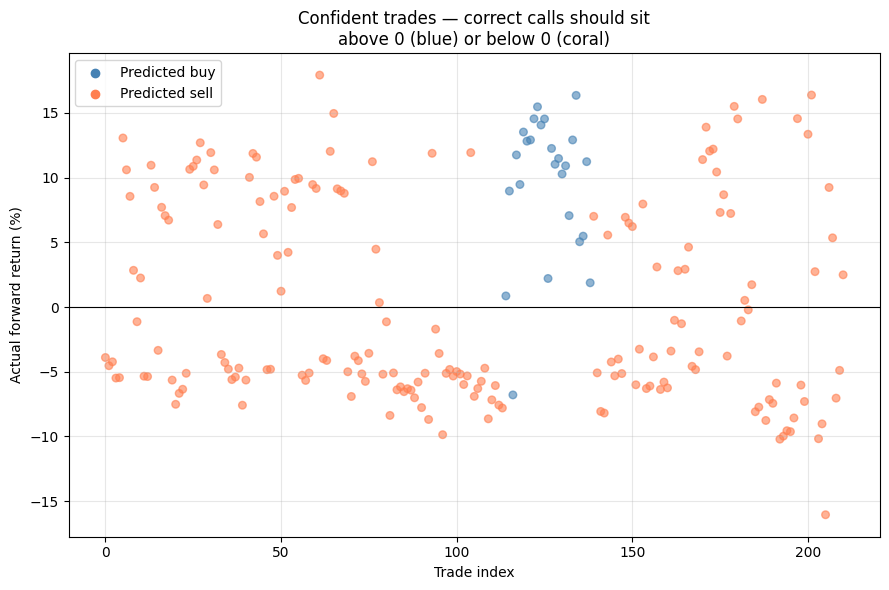

In [11]:
clean = pooled.dropna(subset=feature_cols + ['label'])
unique_dates = np.sort(clean.index.unique())

split_point = int(len(unique_dates) * 0.7)
train_dates = unique_dates[:split_point]
test_dates = unique_dates[split_point:]

X_train = clean.loc[clean.index.isin(train_dates), feature_cols]
y_train = clean.loc[clean.index.isin(train_dates), 'label']

model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

plot_trade_outcomes(pooled, model, feature_cols, test_dates, confidence_threshold=0.6)

It is immediately obvious that the buy predictions are pretty accurate, with all buy predictions laying above the 0% return line. The sell predictions however are all over the place, which is probably what skews the above results. We check directionally to investigate.

In [12]:
direction_results = evaluate_by_direction(lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), pooled, feature_cols, confidence_threshold=0.6)

print(direction_results.to_string())
print(f"\nMean buy_return: {direction_results['buy_return'].mean()*100:.4f}%")
print(f"Mean sell_return: {direction_results['sell_return'].mean()*100:.4f}%")

t, p = stats.ttest_1samp(direction_results['buy_return'].dropna(), 0)
print(f"Buy return vs 0: t={t:.3f}, p={p:.4f}")
t2, p2 = stats.ttest_1samp(direction_results['sell_return'].dropna(), 0)
print(f"Sell return vs 0: t={t2:.3f}, p={p2:.4f}")

    fold  n_buys  n_sells  buy_return  sell_return
0      0      99       37   -0.002542     0.035453
1      1     126       46    0.006868    -0.022302
2      2      37      189    0.021584     0.017706
3      3       8       87   -0.038824     0.014050
4      4      16      283   -0.009285     0.001025
5      5       4      190    0.026337     0.020146
6      6      25      155    0.028719     0.015211
7      7      49       59    0.017355     0.094971
8      8      29       22    0.031302     0.037344
9      9      10       35    0.007999     0.044496
10    10      17       10    0.020381     0.002195
11    11      17       78    0.039605     0.011987
12    12       6       63   -0.011324     0.000547
13    13      25        4    0.014371    -0.008222
14    14      34       57   -0.023728    -0.015241
15    15       5      576    0.023183    -0.018769
16    16       0      994         NaN     0.004439
17    17       0      824         NaN    -0.004604
18    18       0     1080      

The buy returns signal we were testing are statistically insignificant from zero on average, despite looking positive. On the contrary, the sell-return signals seem to be actively wrong, and returning statistically significant buy signals. This is tested below.

In [13]:
inverted_as_buy = direction_results['sell_return'] 
t, p = stats.ttest_1samp(inverted_as_buy.dropna(), 0)
print(f"Treating 'model sell' as a buy signal — mean return: {inverted_as_buy.mean()*100:.4f}%")
print(f"t={t:.3f}, p={p:.4f}")

Treating 'model sell' as a buy signal — mean return: 1.1285%
t=2.898, p=0.0068


It is true that our sell signals were returning buy signals on average. This could be due to a small number of outliers on certain folds skewing statistics, which is tested beneath.

In [14]:
positive_folds = (direction_results['sell_return'] > 0).sum()
total_folds = direction_results['sell_return'].notna().sum()
print(f"{positive_folds}/{total_folds} folds had positive sell_return (favourable for inverted buy)")

26/32 folds had positive sell_return (favourable for inverted buy)


It is clear now that our sell signals were returning buy signals on average of this set of data, else we would have a split that looks approximately 50/50. This is not 100% validated or confirmed as that would require parameter sweeping and other independent confirmation, but is something that looks unusual.

We end this section by briefly analysing the strategy against the typical 'buy and hold' strategy, similarly to what we did in technical_analysis.

In [15]:
comparison = strategy_vs_buy_hold( pooled, feature_cols, lambda: RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), confidence_threshold=0.6)

print(comparison.to_string())
print(f"\nMean strategy return: {comparison['strategy_return'].mean()*100:.3f}%")
print(f"Mean buy & hold:       {comparison['buy_hold_return'].mean()*100:.3f}%")
print(f"Mean excess return:    {comparison['excess_return'].mean()*100:.3f}%")

t, p = stats.ttest_1samp(comparison['excess_return'], 0)
print(f"Excess return vs 0: t={t:.3f}, p={p:.4f}")

    fold  n_confident  strategy_return  buy_hold_return  excess_return
0      0          136        -0.011495         0.005056      -0.016551
1      1          172         0.010996        -0.009906       0.020901
2      2          226        -0.011274         0.010016      -0.021289
3      3           95        -0.016136         0.004691      -0.020828
4      4          299        -0.001467         0.002059      -0.003526
5      5          194        -0.019188         0.010199      -0.029387
6      6          180        -0.009109        -0.005582      -0.003528
7      7          108        -0.044008         0.032483      -0.076492
8      8           51         0.001690         0.010574      -0.008884
9      9           45        -0.032831         0.011821      -0.044652
10    10           27         0.012019         0.001372       0.010647
11    11           95        -0.002755         0.007084      -0.009839
12    12           69        -0.001484         0.004209      -0.005693
13    

See that our strategy is actively worse than just buying and holding across this set of tickers. This leads us to seek other signals for stock direction

## PART 2

We use the cross-return excess return formulation found in "Machine Learning in Finance, From Theory to Practice", authored by "Matthew F. Dixon, Igor Halperin, Paul Bilokon", alongside a discussion around the 'momentum' signal. Start with the book's formulation. It is stated that a signal can be predictive of its own future and correlate with returns, but still not be a profitable strategy due to transaction costs and trade construction. Part of the issue in part 1 was portfolio selection, we chose a random selection of tickers with equal weighting. It was seen in the portfolio optimisation project that this isn't correct, although again that was also a random selection of tickers. The following formulation is followed:


$$
G_t =
\begin{cases}
1 & \text{if } \dfrac{1}{N}\sum_{i} r^i_{t+h,t} - \tilde{r}_{t+h,t} \geq \epsilon \\[2pt]
0 & \text{otherwise}
\end{cases}
$$
where:

$G_t$: label at time t, 1 being portfolio "beat the benchmark", 0 being did not.

$N$: number of tickers in portfolio/universe

$r^i_{t+h,t}$: returns of ticker i between t + h, t  ($h>0$)

$\tilde{r}_{t+h,t}$: returns of the benchmark over the same time period

$\epsilon$: small positive constant. If chosen too big, problem turns into an outlier detection problem. Returns within $\epsilon$ of the market mean can be treated as noise


Explicitly, this formula is not used, but is for inspiration. Below the stocks are ordered by excess returns continuously, from which a top percentile are selected

In [16]:
pooled_v2 = excess_return_target(pooled, horizon=21)

In [17]:
ranked = walk_forward_ranked_portfolio(lambda: RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), 
                                       pooled_v2, feature_cols, train_size=250, test_size=63, embargo=21, top_frac=0.2) #top_frac = 0.2 means top 20% of stocks are selected.

print(f"Total test days: {len(ranked)}")
print(f"Mean top-selected return:  {ranked['top_return'].mean()*100:.4f}%")
print(f"Mean bottom-avoided return: {ranked['bottom_return'].mean()*100:.4f}%")
print(f"Mean universe return:      {ranked['universe_return'].mean()*100:.4f}%")

t, p = stats.ttest_1samp(ranked['top_return'] - ranked['universe_return'], 0)
print(f"\nTop vs universe: t={t:.3f}, p={p:.4f}")
t2, p2 = stats.ttest_rel(ranked['top_return'], ranked['bottom_return'])
print(f"Top vs bottom (paired): t={t2:.3f}, p={p2:.4f}")

Total test days: 2016
Mean top-selected return:  0.4801%
Mean bottom-avoided return: 0.4539%
Mean universe return:      0.4253%

Top vs universe: t=0.851, p=0.3948
Top vs bottom (paired): t=0.256, p=0.7982


There is still no significance when we walk forward with the same machine relative to both the universe return and relative to the bottom avoided return. As another trick to find a signal, we rank the stocks by momentum, the past k days of relative returns, whilst still holding the top 20%.

In [18]:
mom, t, p = momentum_baseline_single(pooled_v2, lookback_col='return_21d', top_frac=0.2, verbose=True)

Momentum top: 0.8008%  bottom: 0.3442%  universe: 0.4512%
Top vs bottom: t=5.175, p=0.0000


There is now some statistical significance between top, bottom and universe. This is done over a 21d rolling window and selecting the top 20% of the portfolio

In [19]:
sweep = momentum_baseline_sweep(pooled_v2)
print(sweep.to_string())

print("\nSignificant (p<0.05) top-vs-bottom results:")
print(sweep[sweep['p_top_vs_bottom'] < 0.05].to_string())

      lookback  top_frac  n_days  top_return  bottom_return  universe_return  top_minus_bottom  p_top_vs_bottom  top_minus_universe  p_top_vs_universe
0    return_5d       0.1    2482      0.7647         0.6413           0.4540            0.1234           0.4363              0.3107             0.0041
1    return_5d       0.2    2482      0.5848         0.6062           0.4540           -0.0213           0.8110              0.1309             0.0181
2    return_5d       0.3    2482      0.5151         0.5484           0.4540           -0.0333           0.6276              0.0611             0.1232
3    return_5d       0.5    2482      0.4422         0.4841           0.4540           -0.0418           0.3731             -0.0118             0.6218
4   return_10d       0.1    2482      0.9878         0.4678           0.4540            0.5200           0.0017              0.5338             0.0000
5   return_10d       0.2    2482      0.7008         0.4646           0.4540            0.2362

The sweep is varied over top fractions (amount of tickers included) of [0.1, 0.2, 0.3, 0.5] and windows of [5d, 10d, 21d, 63d] are used. The data above gives how the relevant statistics vary as they change. To make this more digestible, there is this plot below:

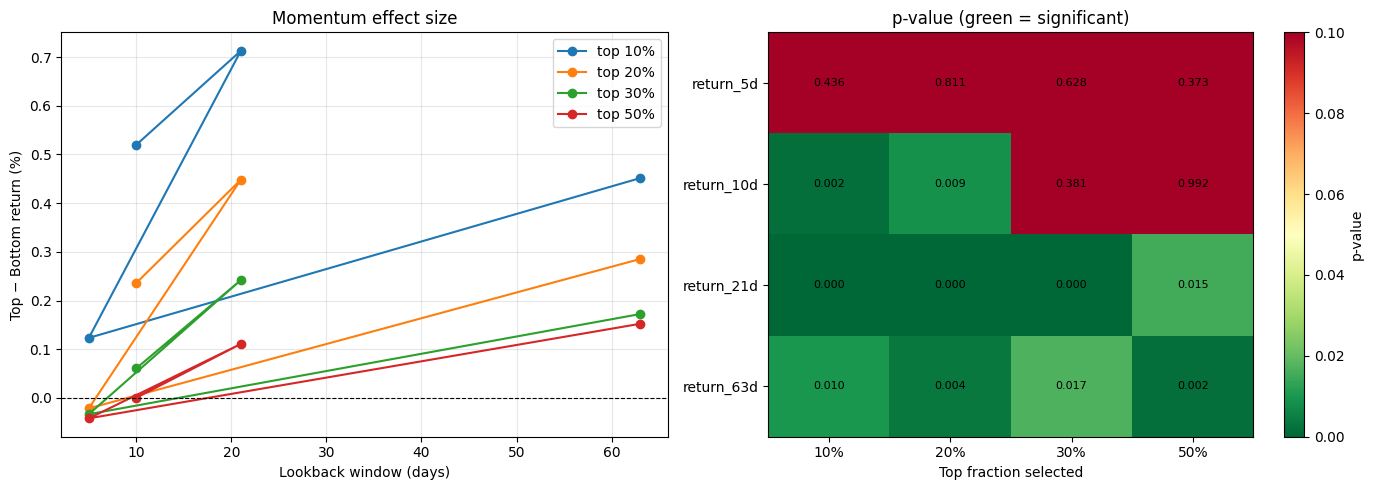

In [20]:
plot_momentum_sweep(sweep)

The sweet spot of windows is seen to be 21d, with 63d being only ever slightly worse option. If we select the top 10%, then a 10d window can be used to yield good results, but as seen in portfolio_optimisation, a more diverse portfolio is generally a better performing one long term, so more tickers and longer windows is prefered. The sweet spot for top fraction selected seems to be around 25%, which is what is used from now on (alongside a 21d window).

We now walk forward using this rule, to see how it fares

In [21]:
mom_wf = walk_forward_momentum_rule(pooled_v2, lookback_col='return_21d', top_frac=0.25, train_size=250, test_size=63, embargo=21)
print(mom_wf.to_string())

print(f"\nMean top return:      {mom_wf['top_return'].mean()*100:.4f}%")
print(f"Mean universe return: {mom_wf['universe_return'].mean()*100:.4f}%")
print(f"Mean excess:          {mom_wf['excess'].mean()*100:.4f}%")

t, p = stats.ttest_1samp(mom_wf['excess'], 0)
print(f"Excess vs 0 across folds: t={t:.3f}, p={p:.4f}")

print(f"\nFraction of folds where top beat universe: {(mom_wf['excess']>0).mean():.2%}")

    fold test_start   test_end  n_days  top_return  universe_return    excess
0      0 2017-10-16 2018-01-16      63    0.011329         0.009913  0.001416
1      1 2018-01-17 2018-04-17      63    0.011799         0.000844  0.010955
2      2 2018-04-18 2018-07-17      63    0.017566         0.010666  0.006900
3      3 2018-07-18 2018-10-15      63    0.004330         0.000381  0.003949
4      4 2018-10-16 2019-01-16      63   -0.000573        -0.004339  0.003766
5      5 2019-01-17 2019-04-17      63    0.012456         0.013581 -0.001125
6      6 2019-04-18 2019-07-18      63    0.002693         0.002176  0.000517
7      7 2019-07-19 2019-10-16      63   -0.005783        -0.000701 -0.005082
8      8 2019-10-17 2020-01-16      63    0.023433         0.013366  0.010066
9      9 2020-01-17 2020-04-17      63    0.007184         0.011875 -0.004691
10    10 2020-04-20 2020-07-17      63    0.018028         0.015567  0.002461
11    11 2020-07-20 2020-10-15      63    0.012498         0.010

The excess return (return relative to the other tickers) is significant as seen by the t-test, making this approach suitably viable. This is the first signal which has real evidence of being suitable at predicting tickers. Notice that no ML has been used for this, just a simple rule. Below we implement ML to see if we can improve the system with this knowledge and combination with other factors that should influence direction.

In [22]:
momentum_features = ['return_21d', 'return_63d', 'volume_trend', 'rel_strength_21d', 'vol_ratio']

ranked_ml = walk_forward_ranked_portfolio(
    lambda: GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42), pooled_v2, momentum_features, target_col='excess_return', train_size=250, test_size=63, embargo=21, top_frac=0.25)

print(f"ML-ranked top return:      {ranked_ml['top_return'].mean()*100:.4f}%")
print(f"ML-ranked universe return: {ranked_ml['universe_return'].mean()*100:.4f}%")
print(f"ML-ranked excess:          {(ranked_ml['top_return']-ranked_ml['universe_return']).mean()*100:.4f}%")

t, p = stats.ttest_rel(ranked_ml['top_return'], ranked_ml['universe_return'])
print(f"ML top vs universe: t={t:.3f}, p={p:.4f}")

print(f"No ML top-momentum: {mom['top'].mean()*100:.4f}% ")


ML-ranked top return:      0.4378%
ML-ranked universe return: 0.4415%
ML-ranked excess:          -0.0037%
ML top vs universe: t=-0.078, p=0.9376
No ML top-momentum: 0.8008% 


The ML-ranked top return is not significant compared to the universe ranked return, and is significantly less than the No machine-learning ranked top momentum. It could be possible that one or two filters are 'throwing the machine off' and making results less accurate, so testing each feature individually seems reasonable.

In [23]:
for extra in ['return_63d', 'volume_trend', 'rel_strength_21d', 'vol_ratio']:
    feats = ['return_21d', extra]
    r = walk_forward_ranked_portfolio(lambda: GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42), pooled_v2, feats, target_col='excess_return', train_size=250, test_size=63, embargo=21, top_frac=0.25)
    excess = (r['top_return'] - r['universe_return']).mean()
    t, p = stats.ttest_rel(r['top_return'], r['universe_return'])
    print(f"return_21d + {extra}: excess={excess*100:.4f}%, p={p:.4f}")

return_21d + return_63d: excess=0.0326%, p=0.4906
return_21d + volume_trend: excess=0.1100%, p=0.0178
return_21d + rel_strength_21d: excess=0.0317%, p=0.4830
return_21d + vol_ratio: excess=0.0814%, p=0.0910


With each individual feature, all excess returns are not significant compared to 0. From this we conclude that, at least with gradient boosting, machine learning does not assist with our goal, and the best approach we found was momentum ranking. We test with a linear regression model to check whether its a gradient boosting issue.

In [24]:
r_lin = walk_forward_ranked_portfolio(lambda: LinearRegression(), pooled_v2, momentum_features, target_col='excess_return', train_size=250, test_size=63, embargo=21, top_frac=0.25)
excess = (r_lin['top_return'] - r_lin['universe_return']).mean()
t, p = stats.ttest_rel(r_lin['top_return'], r_lin['universe_return'])
print(f"Linear, all features: excess={excess*100:.4f}%, p={p:.4f}")

Linear, all features: excess=-0.0425%, p=0.3935


The results are still insignificant compared to 0. We still seek ways to get more signals, which leads us to part 3, involving a completely different approach.

### ADDED SECTION

After the results for our 20 ticker-universe, look to see if results extend to all S&P500 tickers. Rerun non-ML results for this new universe.

In [25]:
sp500 = get_sp500_tickers()
pooled_sp500 = build_multi_ticker_dataset(sp500, period="5y", horizon=21)

/Users/oscarlewis/Desktop/python/trading_portfolio/ml_trading_signals/notebooks/../../past_market_analysis/src/data_loader.py:38: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_details = pd.read_html(response.text)

1 Failed download:
['CLX']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['EXPE']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['QCOM']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['RJF']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['RMD']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['SHW']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['TPL']: TypeError("'NoneType' object is not subscriptable")


Successfully loaded: 493 / 503 tickers
Failed or insufficient data: 10 (['CLX', 'EXPE', 'FDXF', 'HONA', 'QCOM', 'Q', 'RJF', 'RMD', 'SHW', 'TPL'])


In [26]:
pooled_sp500_v2 = excess_return_target(pooled_sp500, horizon=21)
sweep_sp500 = momentum_baseline_sweep(pooled_sp500_v2)


1 Failed download:
['HAS']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['HAL']: TypeError("'NoneType' object is not subscriptable")

1 Failed download:
['CB']: TypeError("'NoneType' object is not subscriptable")


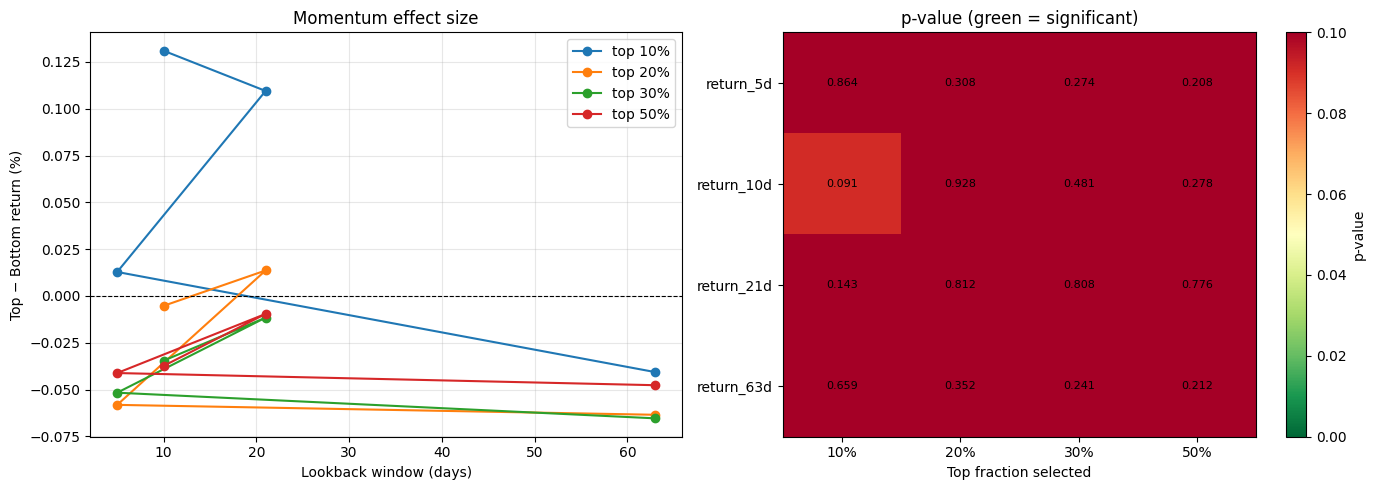

In [31]:
plot_momentum_sweep(sweep_sp500)

In [32]:
mom_wf_sp500 = walk_forward_momentum_rule(
    pooled_sp500_v2, lookback_col='return_21d', top_frac=0.25,
    train_size=250, test_size=63, embargo=21
)

In [33]:
print(mom_wf_sp500.to_string())
print(f"\nMean top return:      {mom_wf_sp500['top_return'].mean()*100:.4f}%")
print(f"Mean universe return: {mom_wf_sp500['universe_return'].mean()*100:.4f}%")
print(f"Mean excess:          {mom_wf_sp500['excess'].mean()*100:.4f}%")

from scipy import stats
t, p = stats.ttest_1samp(mom_wf_sp500['excess'], 0)
print(f"Excess vs 0 (folds): t={t:.3f}, p={p:.4f}")
print(f"Fraction of folds where top beat universe: {(mom_wf_sp500['excess']>0).mean()*100:.2f}%")

    fold test_start   test_end  n_days  top_return  universe_return    excess
0      0 2022-10-14 2023-01-13      63    0.006585         0.008271 -0.001686
1      1 2023-01-17 2023-04-17      63    0.002157         0.000297  0.001860
2      2 2023-04-18 2023-07-18      63    0.010763         0.006701  0.004062
3      3 2023-07-19 2023-10-16      63   -0.006976        -0.006602 -0.000374
4      4 2023-10-17 2024-01-17      63    0.013227         0.013282 -0.000055
5      5 2024-01-18 2024-04-17      63    0.007653         0.004759  0.002894
6      6 2024-04-18 2024-07-18      63    0.003257         0.004516 -0.001259
7      7 2024-07-19 2024-10-16      63    0.006844         0.007306 -0.000462
8      8 2024-10-17 2025-01-17      63    0.003387         0.001261  0.002126
9      9 2025-01-21 2025-04-21      63   -0.008560        -0.004033 -0.004527
10    10 2025-04-22 2025-07-22      63    0.018491         0.015053  0.003439
11    11 2025-07-23 2025-10-20      63    0.003385         0.002

See that the results do not generalise to entire S&P500. Momentum sweep comes up insignificant across each return length and top fraction. Mean top return comes up insignificant against 0. This tells us that there is something special about our selection of tickers, the properties of the tickers we selected, whether that be the liquidity, market-cap or other properties.

## PART 3


As found above, momentum is a useful signal for predicting positive performance of tickers compared to the market. We look for other relevent signals here, such as the PE-ratio (price-earnings, how much a share costs relative to the companies earnings per share) and ROE (return on equity).

In [27]:
fund = build_fundamental_features(tickers)
print(fund)
print(f"\nMissing data per column:")
print(fund.isna().sum())

          pe_ratio   pb_ratio      roe  debt_to_equity  profit_margin  \
ticker                                                                  
AAPL     35.567165  42.091034  1.48751          78.445        0.27619   
MSFT     26.915972   8.120205  0.34039          29.118        0.40305   
GOOGL    17.227410   6.742573  0.48676          18.859        0.54771   
AMZN     20.926905   5.088957  0.30558          45.617        0.17440   
NVDA     33.651608  27.229864  1.14288           6.555        0.62966   
META     20.489275   5.310184  0.29848          42.997        0.29835   
TSLA    308.530000  15.289733  0.04667          18.373        0.03671   
JPM      15.503632   2.721735  0.17789             NaN        0.34921   
JNJ      31.358053   7.669765  0.25742          57.709        0.21482   
XOM      21.253540   2.617945  0.12584          15.921        0.09072   
WMT      40.742958   9.766206  0.24132          74.816        0.03135   
PG       21.659878   6.258116  0.30290          64.

This is live data, hence as of the time of the original committing, we are not sure on the results. We create a composite signal, which encourages a low P-E ratio, and high ROE. This can be seen visibly in the plot below. Over time, we will iteratively apply the function 'forward_evaluation_tracking' which will see how our hypothesis works. Backtesting cannot be used as a result of limited data over time (~4 quarters of available data, not long enough for a robust solution).

In [28]:
log = start_forward_tracking(tickers, fund)

Logged 19 tickers to ../data/forward_test_log.csv

Top quintile (cheap + profitable): ['ADBE', 'GOOGL', 'HD', 'AMZN']
Bottom quintile: ['JNJ', 'DIS', 'CSCO', 'WMT', 'AMD', 'TSLA']


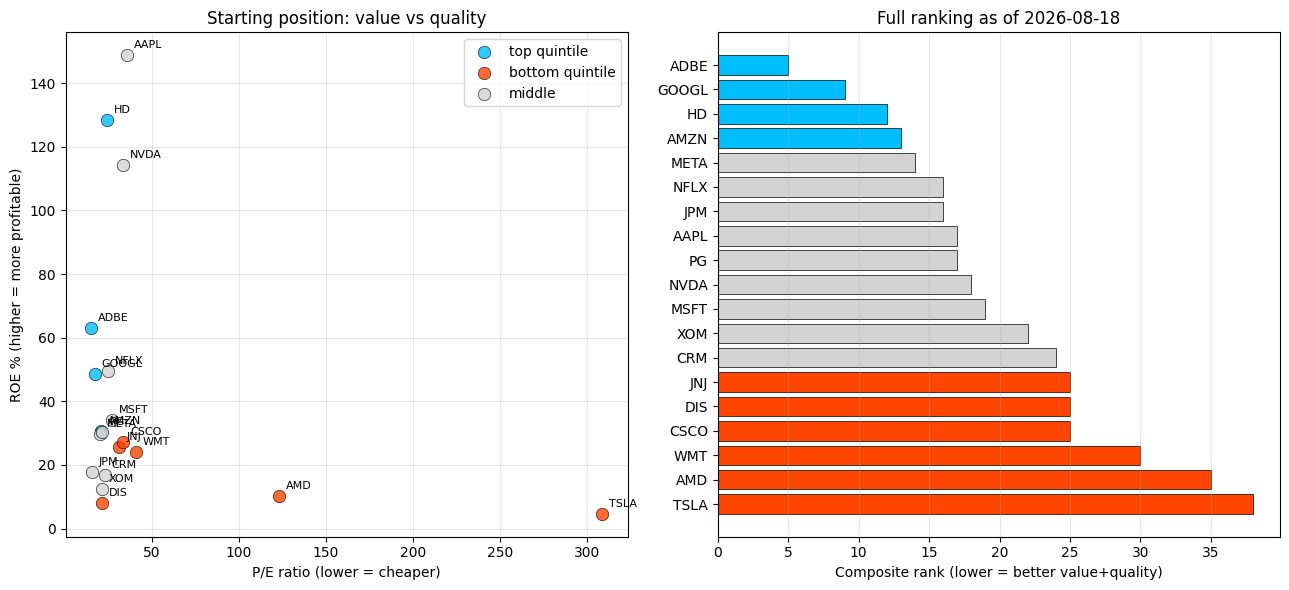


As time progresses we predict that blue (top quintile) should on average outperform orange/red (bottom quintile). Reapply function with forward_evaluation_tracking


In [29]:
plot_forward_test_setup(log)

In [30]:
forward_evaluation_tracking(log_path='../data/forward_test_log.csv')

Days since start date: 0
                     mean  count
group                           
bottom_quintile -0.000029      6
middle          -0.000101      9
top_quintile    -0.000175      4


,ticker,start_date,start_price,pe_ratio,roe,composite_rank,group,current_return
0,ADBE,2026-08-18,265.899994,15.211671,0.62954,5.0,top_quintile,-0.000564
1,GOOGL,2026-08-18,343.244995,17.227410,0.48676,9.0,top_quintile,0.000014
2,HD,2026-08-18,339.750000,24.113556,1.28380,12.0,top_quintile,0.000000
3,AMZN,2026-08-18,260.279999,20.926905,0.30558,13.0,top_quintile,-0.000152
4,META,2026-08-18,544.369995,20.489275,0.29848,14.0,middle,-0.000147
5,NFLX,2026-08-18,78.504997,24.683650,0.49541,16.0,middle,-0.000064
6,JPM,2026-08-18,361.929993,15.503632,0.17789,16.0,middle,-0.000207
7,AAPL,2026-08-18,309.769989,35.567165,1.48751,17.0,middle,-0.000113
8,PG,2026-08-18,143.610001,21.659878,0.30290,17.0,middle,-0.000104
9,NVDA,2026-08-18,219.779800,33.651608,1.14288,18.0,middle,-0.000050
